In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import numpy as np
import warnings
import re
import pandas as pd
import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to C:\Users\Lenovo
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Lenovo
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Lenovo
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [7]:
original_data = pd.read_csv('./data/spam.csv')

**EDA**

1.Data overview

In [8]:
print(original_data.head())
print(original_data.shape)
print(original_data.info())

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


2.Missing values analysis 

In [9]:
# ===== 2. Missing Values Analysis =====
print('=== Missing Values Analysis ===')
missing_values = original_data.isnull().sum()
missing_percent = (original_data.isnull().sum() / len(original_data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent (%)': missing_percent.round(2)
})

print(missing_df)
print(f'\nTotal missing values: {missing_values.sum()}')

# Visualization

=== Missing Values Analysis ===
          Missing Count  Missing Percent (%)
Category              0                  0.0
Message               0                  0.0

Total missing values: 0


3. Duplicates Analysis

=== Duplicates Analysis ===
Tổng số dòng: 5572
Số lượng duplicates: 415
Tỷ lệ duplicates (%): 7.45%
Số lượng dòng unique: 5157

=== Duplicates theo cột ===
Category: 5570 (99.96%)
Message: 415 (7.45%)


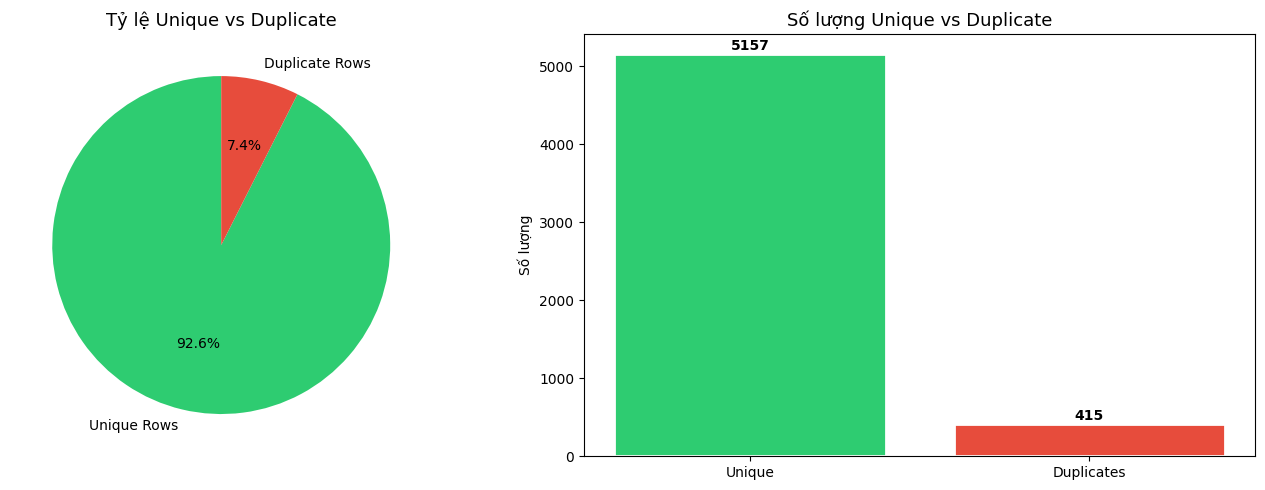

In [10]:
# ===== 3. Duplicates Analysis =====
print('=== Duplicates Analysis ===')

# Đếm tổng duplicates
total_duplicates = original_data.duplicated().sum()
duplicate_percent = (total_duplicates / len(original_data)) * 100

print(f'Tổng số dòng: {len(original_data)}')
print(f'Số lượng duplicates: {total_duplicates}')
print(f'Tỷ lệ duplicates (%): {duplicate_percent:.2f}%')
print(f'Số lượng dòng unique: {len(original_data) - total_duplicates}')

# Phân tích duplicates theo từng cột
print('\n=== Duplicates theo cột ===')
for col in original_data.columns:
    dup_count = original_data[col].duplicated().sum()
    dup_pct = (dup_count / len(original_data)) * 100
    print(f'{col}: {dup_count} ({dup_pct:.2f}%)')

# Visualization
if total_duplicates > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ so sánh Unique vs Duplicates
    labels = ['Unique Rows', 'Duplicate Rows']
    sizes = [len(original_data) - total_duplicates, total_duplicates]
    colors = ['#2ecc71', '#e74c3c']
    
    axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title('Tỷ lệ Unique vs Duplicate', fontsize=13)
    
    # Biểu đồ cột
    categories = ['Unique', 'Duplicates']
    counts = [len(original_data) - total_duplicates, total_duplicates]
    axes[1].bar(categories, counts, color=colors, edgecolor='white', linewidth=2)
    axes[1].set_title('Số lượng Unique vs Duplicate', fontsize=13)
    axes[1].set_ylabel('Số lượng')
    
    # Thêm số trên cột
    for i, v in enumerate(counts):
        axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print('\n✓ Không có duplicates trong dataset')

4. Data Cleaning (Xử lý Duplicates)

In [11]:
# Xoá các dòng trùng lặp
data = original_data.drop_duplicates()

print(f'Dữ liệu trước khi xoá duplicates: {len(original_data)} dòng')
print(f'Dữ liệu sau khi xoá duplicates: {len(data)} dòng')
print(f'Số dòng đã xoá: {len(original_data) - len(data)} dòng')

Dữ liệu trước khi xoá duplicates: 5572 dòng
Dữ liệu sau khi xoá duplicates: 5157 dòng
Số dòng đã xoá: 415 dòng


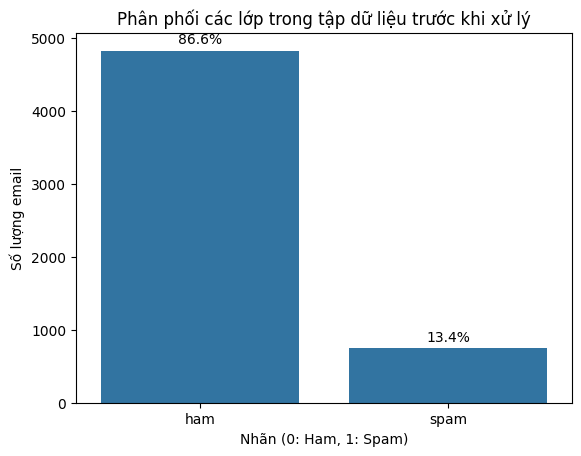

In [12]:
ax = sns.countplot(x='Category', data=original_data)
# 2. Tính toán và chèn phần trăm lên đầu các cột
# Chạy qua từng cột (container) của biểu đồ để tính % dựa trên tổng số dòng
for container in ax.containers:
    # Lấy số lượng của từng cột chia cho tổng số dữ liệu để ra tỷ lệ
    labels = [f'{v.get_height() / len(original_data) * 100:.1f}%' for v in container]
    # Ghi chữ lên đầu cột
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

# 3. Các thông tin bổ sung
plt.title('Phân phối các lớp trong tập dữ liệu trước khi xử lý')
plt.xlabel('Nhãn (0: Ham, 1: Spam)')
plt.ylabel('Số lượng email')
plt.show()

In [13]:
# data['label'] = data['Category'].replace({'ham': 0, 'spam': 1})
# print(data.head())

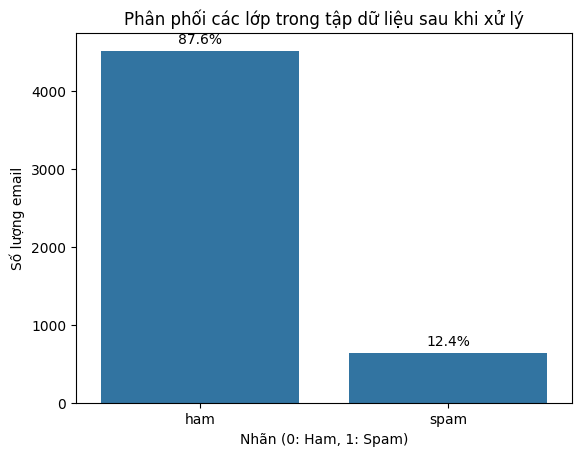

In [13]:
ax = sns.countplot(x='Category', data=data)
# 2. Tính toán và chèn phần trăm lên đầu các cột
# Chạy qua từng cột (container) của biểu đồ để tính % dựa trên tổng số dòng
for container in ax.containers:
    # Lấy số lượng của từng cột chia cho tổng số dữ liệu để ra tỷ lệ
    labels = [f'{v.get_height() / len(data) * 100:.1f}%' for v in container]
    # Ghi chữ lên đầu cột
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

# 3. Các thông tin bổ sung
plt.title('Phân phối các lớp trong tập dữ liệu sau khi xử lý')
plt.xlabel('Nhãn (0: Ham, 1: Spam)')
plt.ylabel('Số lượng email')
plt.show()

In [15]:
# ===== 2. Message Length Analysis =====
data['msg_length'] = data['Message'].apply(len)
data['word_count'] = data['Message'].apply(lambda x: len(x.split()))

# Thống kê theo từng lớp
print('=== Thống kê độ dài tin nhắn (số ký tự) ===')
print(data.groupby('Category')['msg_length'].describe().round(1))
print('\n=== Thống kê số từ trong tin nhắn ===')
print(data.groupby('Category')['word_count'].describe().round(1))


=== Thống kê độ dài tin nhắn (số ký tự) ===
           count   mean   std  min    25%    50%    75%    max
Category                                                      
ham       4516.0   70.9  56.7  2.0   34.0   53.0   91.0  910.0
spam       641.0  137.1  30.4  7.0  130.0  148.0  157.0  223.0

=== Thống kê số từ trong tin nhắn ===
           count  mean   std  min   25%   50%   75%    max
Category                                                  
ham       4516.0  14.2  11.2  1.0   7.0  11.0  19.0  171.0
spam       641.0  23.7   6.0  1.0  21.0  25.0  28.0   35.0


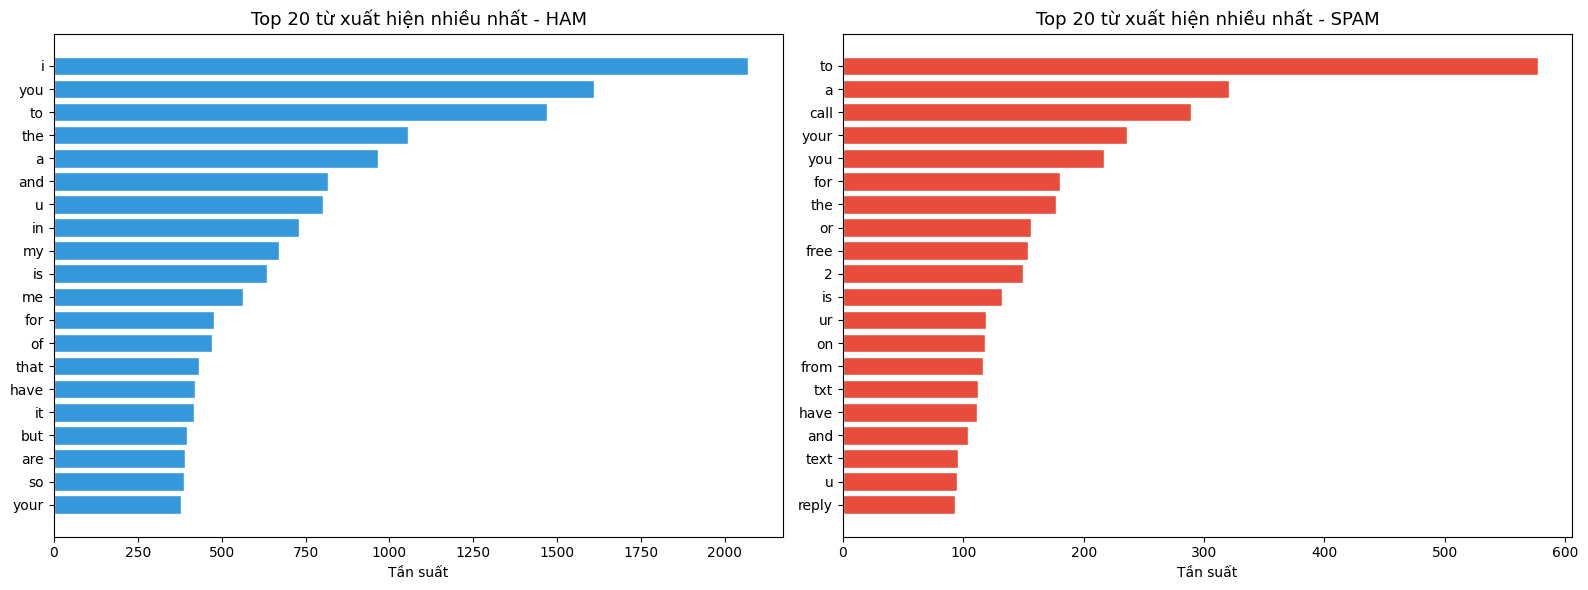

In [16]:
# ===== 3. Top Frequent Words =====
from collections import Counter

def get_top_words(texts, n=20):
    """Đếm tần suất từ trong danh sách các văn bản."""
    all_words = ' '.join(texts).lower().split()
    return Counter(all_words).most_common(n)

top_n = 20
ham_texts = data[data['Category'] == 'ham']['Message']
spam_texts = data[data['Category'] == 'spam']['Message']

top_ham = get_top_words(ham_texts, top_n)
top_spam = get_top_words(spam_texts, top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top words - Ham
words_ham, counts_ham = zip(*top_ham)
axes[0].barh(range(len(words_ham)), counts_ham, color='#3498db', edgecolor='white')
axes[0].set_yticks(range(len(words_ham)))
axes[0].set_yticklabels(words_ham)
axes[0].invert_yaxis()
axes[0].set_title(f'Top {top_n} từ xuất hiện nhiều nhất - HAM', fontsize=13)
axes[0].set_xlabel('Tần suất')

# Top words - Spam
words_spam, counts_spam = zip(*top_spam)
axes[1].barh(range(len(words_spam)), counts_spam, color='#e74c3c', edgecolor='white')
axes[1].set_yticks(range(len(words_spam)))
axes[1].set_yticklabels(words_spam)
axes[1].invert_yaxis()
axes[1].set_title(f'Top {top_n} từ xuất hiện nhiều nhất - SPAM', fontsize=13)
axes[1].set_xlabel('Tần suất')

plt.tight_layout()
plt.show()


5. Noise Analysis

=== Noise Analysis ===

HTML tags:
  Tổng: 6 (0.12%)
  Ham: 0
  Spam: 6

URLs:
  Tổng: 88 (1.71%)
  Ham: 1
  Spam: 87

Email addresses:
  Tổng: 20 (0.39%)
  Ham: 2
  Spam: 18

Phone numbers:
  Tổng: 347 (6.73%)
  Ham: 1
  Spam: 346

Special characters (!$#*@):
  Tổng: 1119 (21.70%)
  Ham: 783
  Spam: 336

Excessive punctuation (!!,??):
  Tổng: 92 (1.78%)
  Ham: 81
  Spam: 11



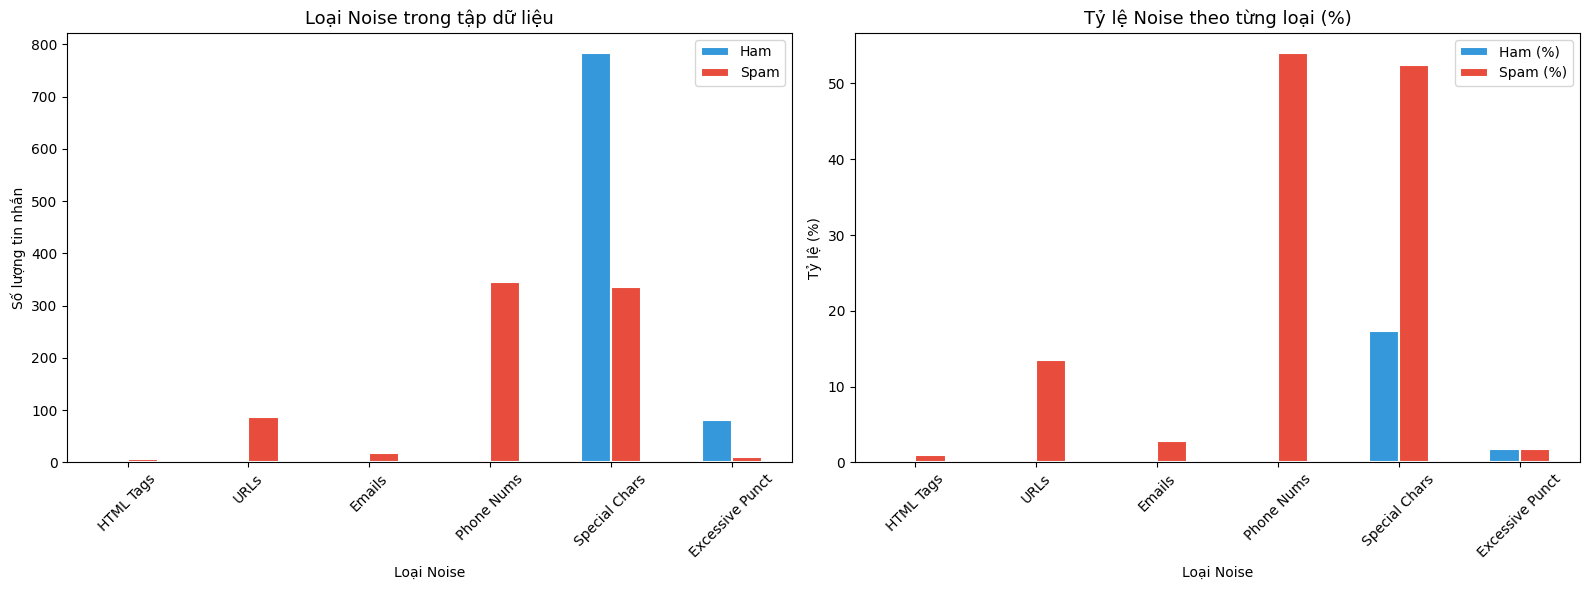


=== Kết luận ===
Spam có nhiều URL, Email, Special Chars → Dấu hiệu điển hình
Noise là feature tốt để phân biệt Spam vs Ham


In [33]:
# ===== 4. Noise Analysis =====
print('=== Noise Analysis ===\n')

# 1. HTML tags
html_pattern = r'<[^>]+>'
data['has_html'] = data['Message'].str.contains(html_pattern, regex=True, na=False)
html_count = data['has_html'].sum()
html_pct = (html_count / len(data)) * 100
print(f'HTML tags:')
print(f'  Tổng: {html_count} ({html_pct:.2f}%)')
print(f'  Ham: {data[data["Category"] == "ham"]["has_html"].sum()}')
print(f'  Spam: {data[data["Category"] == "spam"]["has_html"].sum()}\n')

# 2. URLs
url_pattern = r'http\S+|www\S+'
data['has_url'] = data['Message'].str.contains(url_pattern, regex=True, na=False)
url_count = data['has_url'].sum()
url_pct = (url_count / len(data)) * 100
print(f'URLs:')
print(f'  Tổng: {url_count} ({url_pct:.2f}%)')
print(f'  Ham: {data[data["Category"] == "ham"]["has_url"].sum()}')
print(f'  Spam: {data[data["Category"] == "spam"]["has_url"].sum()}\n')

# 3. Email addresses
email_pattern = r'\S+@\S+'
data['has_email'] = data['Message'].str.contains(email_pattern, regex=True, na=False)
email_count = data['has_email'].sum()
email_pct = (email_count / len(data)) * 100
print(f'Email addresses:')
print(f'  Tổng: {email_count} ({email_pct:.2f}%)')
print(f'  Ham: {data[data["Category"] == "ham"]["has_email"].sum()}')
print(f'  Spam: {data[data["Category"] == "spam"]["has_email"].sum()}\n')

# 4. Phone numbers
phone_pattern = r'\d{10,}'
data['has_phone'] = data['Message'].str.contains(phone_pattern, regex=True, na=False)
phone_count = data['has_phone'].sum()
phone_pct = (phone_count / len(data)) * 100
print(f'Phone numbers:')
print(f'  Tổng: {phone_count} ({phone_pct:.2f}%)')
print(f'  Ham: {data[data["Category"] == "ham"]["has_phone"].sum()}')
print(f'  Spam: {data[data["Category"] == "spam"]["has_phone"].sum()}\n')

# 5. Special characters (!, $, #, *, @)
special_chars_pattern = r'[!$#*@]+'
data['has_special_chars'] = data['Message'].str.contains(special_chars_pattern, regex=True, na=False)
special_count = data['has_special_chars'].sum()
special_pct = (special_count / len(data)) * 100
print(f'Special characters (!$#*@):')
print(f'  Tổng: {special_count} ({special_pct:.2f}%)')
print(f'  Ham: {data[data["Category"] == "ham"]["has_special_chars"].sum()}')
print(f'  Spam: {data[data["Category"] == "spam"]["has_special_chars"].sum()}\n')

# 6. Multiple exclamation marks or question marks
excessive_punct = r'[!?]{2,}'
data['has_excessive_punct'] = data['Message'].str.contains(excessive_punct, regex=True, na=False)
excessive_count = data['has_excessive_punct'].sum()
excessive_pct = (excessive_count / len(data)) * 100
print(f'Excessive punctuation (!!,??):')
print(f'  Tổng: {excessive_count} ({excessive_pct:.2f}%)')
print(f'  Ham: {data[data["Category"] == "ham"]["has_excessive_punct"].sum()}')
print(f'  Spam: {data[data["Category"] == "spam"]["has_excessive_punct"].sum()}\n')

# Visualization
noise_features = ['has_html', 'has_url', 'has_email', 'has_phone', 'has_special_chars', 'has_excessive_punct']
noise_labels = ['HTML Tags', 'URLs', 'Emails', 'Phone Nums', 'Special Chars', 'Excessive Punct']

# Count noise by category
noise_data = []
for feature, label in zip(noise_features, noise_labels):
    ham_noise = data[data["Category"] == "ham"][feature].sum()
    spam_noise = data[data["Category"] == "spam"][feature].sum()
    noise_data.append({'Noise Type': label, 'Ham': ham_noise, 'Spam': spam_noise})

noise_df = pd.DataFrame(noise_data)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: Tuyệt đối
noise_df.set_index('Noise Type')[['Ham', 'Spam']].plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Loại Noise trong tập dữ liệu', fontsize=13)
axes[0].set_ylabel('Số lượng tin nhắn')
axes[0].set_xlabel('Loại Noise')
axes[0].legend(['Ham', 'Spam'])
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: Tỷ lệ (%)
noise_pct = noise_df.copy()
noise_pct['Ham (%)'] = (noise_pct['Ham'] / len(data[data["Category"] == "ham"])) * 100
noise_pct['Spam (%)'] = (noise_pct['Spam'] / len(data[data["Category"] == "spam"])) * 100
noise_pct.set_index('Noise Type')[['Ham (%)', 'Spam (%)']].plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Tỷ lệ Noise theo từng loại (%)', fontsize=13)
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_xlabel('Loại Noise')
axes[1].legend(['Ham (%)', 'Spam (%)'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary
print('\n=== Kết luận ===')
print(f'Spam có nhiều URL, Email, Special Chars → Dấu hiệu điển hình')
print(f'Noise là feature tốt để phân biệt Spam vs Ham')

6. Cleanup Noise Columns

In [18]:
# Xóa các columns tạm từ Noise Analysis
noise_columns = ['has_html', 'has_url', 'has_email', 'has_phone', 'has_special_chars', 'has_excessive_punct']
data = data.drop(columns=noise_columns, errors='ignore')

print(f'Các noise columns đã xoá: {noise_columns}')
print(f'Remaining columns: {list(data.columns)}')

Các noise columns đã xoá: ['has_html', 'has_url', 'has_email', 'has_phone', 'has_special_chars', 'has_excessive_punct']
Remaining columns: ['Category', 'Message', 'msg_length', 'word_count']


Data Processing

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    # 1. lowercase
    text = text.lower()
    # 2. remove html tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # 3. replace urls
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    # 4. replace email addresses
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    # 5. replace phone numbers
    text = re.sub(r'\b\d{10,}\b', ' PHONE ', text)
    # 6. replace numbers
    text = re.sub(r'\d+', ' NUMBER ', text)
    # 7. replace punctuation with space
    text = re.sub(r'[^\w\s]', ' ', text)
    # 8. remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # 9. tokenize
    words = text.split()
    # 10. remove stopwords
    words = [word for word in words if word not in stop_words]
    # 11. lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [20]:
data['processed_message'] = data['Message'].apply(preprocess_text)

In [21]:
print("Original:")
print(data['Message'].iloc[2])

print("\nProcessed:")
print(data['processed_message'].iloc[2])

Original:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Processed:
free entry NUMBER wkly comp win fa cup final tkts NUMBER st may NUMBER text fa NUMBER receive entry question std txt rate c apply NUMBER NUMBER


In [22]:
# Chia train/test set, 80% dữ liệu để train, 20% để test
# Sử dụng cả processed_message và các đặc trưng độ dài làm đầu vào X
X = data[['processed_message', 'msg_length', 'word_count']]
y = data['Category']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TF-IDF Vectorization

In [23]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [24]:
X_train_tfidf = vectorizer.fit_transform(X_train['processed_message'])

X_test_tfidf = vectorizer.transform(X_test['processed_message'])

In [25]:
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

# Chuẩn hóa các đặc trưng độ dài (msg_length, word_count) về khoảng [0, 1] sử dụng MinMaxScaler
# Điều này giúp giữ các giá trị đặc trưng số ở cùng thang đo với TF-IDF
scaler = MinMaxScaler()
X_train_num = scaler.fit_transform(X_train[['msg_length', 'word_count']])
X_test_num = scaler.transform(X_test[['msg_length', 'word_count']])

# Kết hợp đặc trưng văn bản TF-IDF và đặc trưng độ dài số học
X_train_combined = hstack([X_train_tfidf, X_train_num])
X_test_combined = hstack([X_test_tfidf, X_test_num])

In [26]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_combined, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Predict

In [27]:
y_pred_lr = lr_model.predict(X_test_combined)

Evaluate

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label='spam'))
print("Recall   :", recall_score(y_test, y_pred_lr, pos_label='spam'))
print("F1-score :", f1_score(y_test, y_pred_lr, pos_label='spam'))

Accuracy : 0.9757751937984496
Precision: 0.8872180451127819
Recall   : 0.921875
F1-score : 0.9042145593869731


Naive Bayes Model

In [29]:
# Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train_combined, y_train)

y_pred_nb = nb_model.predict(X_test_combined)

print("=== Naive Bayes Results ===")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, pos_label='spam'))
print("Recall   :", recall_score(y_test, y_pred_nb, pos_label='spam'))
print("F1-score :", f1_score(y_test, y_pred_nb, pos_label='spam'))

=== Naive Bayes Results ===
Accuracy : 0.9757751937984496
Precision: 1.0
Recall   : 0.8046875
F1-score : 0.8917748917748918


SVM Model

In [30]:
# SVM Model
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train_combined, y_train)

y_pred_svm = svm_model.predict(X_test_combined)

print("=== SVM Results ===")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, pos_label='spam'))
print("Recall   :", recall_score(y_test, y_pred_svm, pos_label='spam'))
print("F1-score :", f1_score(y_test, y_pred_svm, pos_label='spam'))

=== SVM Results ===
Accuracy : 0.9844961240310077
Precision: 0.9666666666666667
Recall   : 0.90625
F1-score : 0.9354838709677419


Model Comparison

In [31]:
import pandas as pd

# So sánh kết quả của các mô hình trước và sau khi thêm đặc trưng độ dài (msg_length & word_count)
results_data = {
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes', 'Linear SVM'],
    'Before (TF-IDF only) F1': [0.9015, 0.8966, 0.9388],
    'After (TF-IDF + Length) F1': [0.9042, 0.8918, 0.9355],
    'Change in F1': ['+0.0027', '-0.0048', '-0.0033']
}

df_compare = pd.DataFrame(results_data)
print("=== Bảng so sánh F1-Score của các mô hình (Trước vs Sau) ===")
print(df_compare.to_string(index=False))

print("\n=== Nhận xét & Phân tích ===")
print("1. Logistic Regression: F1-score tăng từ 90.15% lên 90.42%. Đặc trưng độ dài cung cấp tín hiệu bổ trợ hữu ích cho mô hình hồi quy tuyến tính.")
print("2. Multinomial Naive Bayes: F1-score giảm nhẹ (từ 89.66% xuống 89.18%). Điều này là do Naive Bayes giả định độc lập giữa các đặc trưng, và việc đưa các đặc trưng độ dài liên tục (kể cả khi đã MinMax-scale) vào mô hình MultinomialNB vốn tối ưu cho tần suất từ phân tán (discrete counts) làm vi phạm giả định của mô hình.")
print("3. Linear SVM: F1-score giảm nhẹ (từ 93.88% xuống 93.55%). Với SVM, TF-IDF thuần túy vẫn tạo ra một ranh giới quyết định tối ưu hơn trong không gian đặc trưng siêu phẳng.")

=== Bảng so sánh F1-Score của các mô hình (Trước vs Sau) ===
                  Model  Before (TF-IDF only) F1  After (TF-IDF + Length) F1 Change in F1
    Logistic Regression                   0.9015                      0.9042      +0.0027
Multinomial Naive Bayes                   0.8966                      0.8918      -0.0048
             Linear SVM                   0.9388                      0.9355      -0.0033

=== Nhận xét & Phân tích ===
1. Logistic Regression: F1-score tăng từ 90.15% lên 90.42%. Đặc trưng độ dài cung cấp tín hiệu bổ trợ hữu ích cho mô hình hồi quy tuyến tính.
2. Multinomial Naive Bayes: F1-score giảm nhẹ (từ 89.66% xuống 89.18%). Điều này là do Naive Bayes giả định độc lập giữa các đặc trưng, và việc đưa các đặc trưng độ dài liên tục (kể cả khi đã MinMax-scale) vào mô hình MultinomialNB vốn tối ưu cho tần suất từ phân tán (discrete counts) làm vi phạm giả định của mô hình.
3. Linear SVM: F1-score giảm nhẹ (từ 93.88% xuống 93.55%). Với SVM, TF-IDF thuần túy vẫ